In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Load dataset
dataset_path = "/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

In [4]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])

In [5]:
# Convert symptom columns to description
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

In [7]:
# Load tokenizers
electra_tokenizer = AutoTokenizer.from_pretrained("google/electra-base-discriminator")
ernie_tokenizer = AutoTokenizer.from_pretrained("nghuyong/ernie-2.0-base-en")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [8]:
class SymptomHybridDataset(Dataset):
    def __init__(self, texts, labels, electra_tokenizer, ernie_tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.electra_tokenizer = electra_tokenizer
        self.ernie_tokenizer = ernie_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        electra_encoding = self.electra_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        ernie_encoding = self.ernie_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {
            "electra": {k: v.squeeze(0) for k, v in electra_encoding.items()},
            "ernie": {k: v.squeeze(0) for k, v in ernie_encoding.items()},
            "label": torch.tensor(self.labels[idx])
        }


In [9]:
train_dataset = SymptomHybridDataset(X_train, y_train, electra_tokenizer, ernie_tokenizer)
test_dataset = SymptomHybridDataset(X_test, y_test, electra_tokenizer, ernie_tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [10]:
class ERNIE_ELECTRA_Classifier(nn.Module):
    def __init__(self, num_labels):
        super(ERNIE_ELECTRA_Classifier, self).__init__()
        self.num_labels = num_labels

        self.electra = AutoModel.from_pretrained("google/electra-base-discriminator")
        self.ernie = AutoModel.from_pretrained("nghuyong/ernie-2.0-en")

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.electra.config.hidden_size + self.ernie.config.hidden_size, num_labels)

    def forward(self, electra_input, ernie_input):
        electra_outputs = self.electra(**electra_input)
        ernie_outputs = self.ernie(**ernie_input)

        # Take [CLS] token representations
        electra_cls = electra_outputs.last_hidden_state[:, 0, :]
        ernie_cls = ernie_outputs.last_hidden_state[:, 0, :]

        combined = torch.cat((electra_cls, ernie_cls), dim=1)
        out = self.dropout(combined)
        return self.classifier(out)

In [11]:
# Initialize model
model = ERNIE_ELECTRA_Classifier(num_labels=len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

2025-05-27 04:03:14.620504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748318595.112445      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748318595.228980      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [12]:
# Training loop
num_epochs = 4
train_loss_values, test_loss_values = [], []
train_accuracies, test_accuracies = [], []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train, total_train = 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        electra_inputs = {k: v.to(device) for k, v in batch["electra"].items()}
        ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
        labels = batch["label"].to(device)

        outputs = model(electra_inputs, ernie_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    model.eval()
    total_test_loss = 0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for batch in test_loader:
            electra_inputs = {k: v.to(device) for k, v in batch["electra"].items()}
            ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
            labels = batch["label"].to(device)

            outputs = model(electra_inputs, ernie_inputs)
            loss = criterion(outputs, labels)

            total_test_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    train_loss_values.append(avg_train_loss)
    test_loss_values.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {test_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")

Epoch 1: Train Loss = 1.3079, Train Acc = 0.7284, Test Loss = 0.5217, Test Acc = 0.8353
Epoch 2: Train Loss = 0.4984, Train Acc = 0.8413, Test Loss = 0.4535, Test Acc = 0.8449
Epoch 3: Train Loss = 0.4367, Train Acc = 0.8505, Test Loss = 0.4305, Test Acc = 0.8475
Epoch 4: Train Loss = 0.4065, Train Acc = 0.8559, Test Loss = 0.4277, Test Acc = 0.8475

Total Training Time: 37089.29 seconds


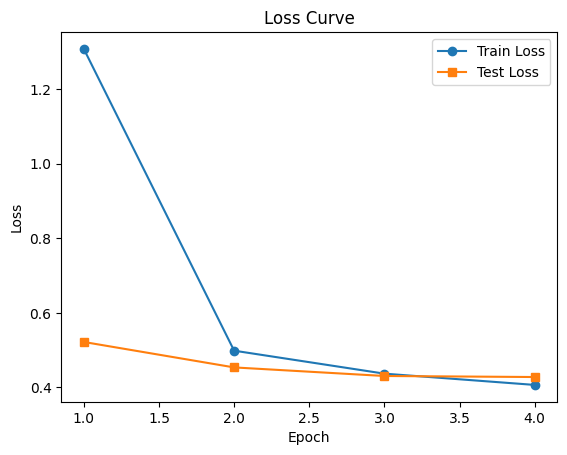

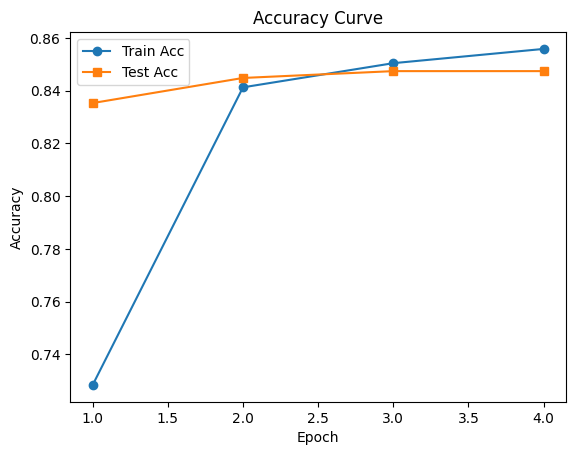

In [17]:
# Plotting
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), test_loss_values, marker='s', label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Acc')
plt.plot(range(1, num_epochs+1), test_accuracies, marker='s', label='Test Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [18]:
# Final evaluation
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        electra_inputs = {k: v.to(device) for k, v in batch["electra"].items()}
        ernie_inputs = {k: v.to(device) for k, v in batch["ernie"].items()}
        labels = batch["label"].to(device)

        outputs = model(electra_inputs, ernie_inputs)
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_))


Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       1.00      1.00      1.00        20
                                        abdominal hernia       0.90      0.99      0.94        81
                                         abscess of nose       0.68      0.90      0.77        58
                                     abscess of the lung       1.00      0.83      0.91         6
                                  abscess of the pharynx       0.97      0.89      0.93        63
                                    acanthosis nigricans       1.00      0.50      0.67         6
                                               acariasis       0.83      1.00      0.91         5
                                               achalasia       0.58      0.90      0.71        20
                                                    acne       0.59      0.77      0.67      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.